In [54]:
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [55]:
iris = load_iris()
x = pd.DataFrame(iris.data)
x.columns = iris.feature_names
y = pd.DataFrame(iris.target)


<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

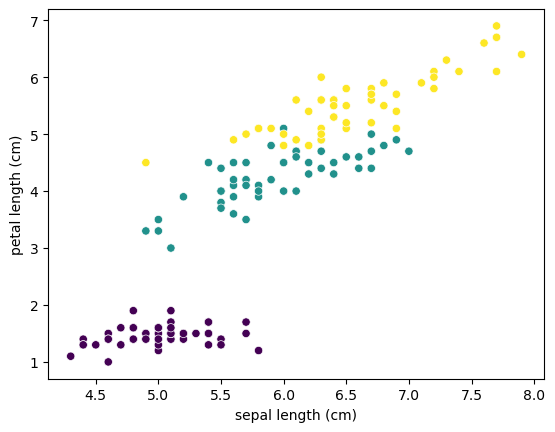

In [56]:
# visualization
import seaborn as sns
sns.scatterplot(x=x.iloc[:,0], y=x.iloc[:,2], c = y)

In [57]:
# scaled our data
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

<Axes: >

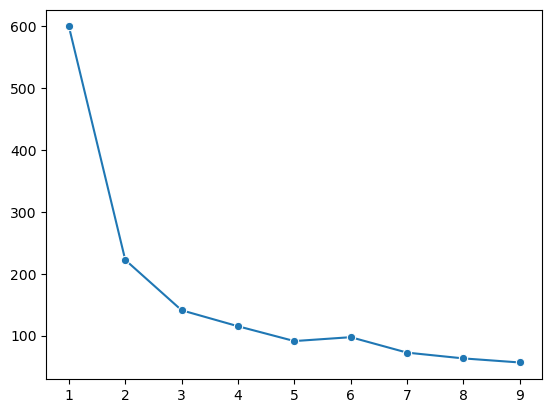

In [58]:
# elbow method to find the best value of k
wcss = []
for k in range (1,10):
    km = KMeans(n_clusters=k)
    label = km.fit_predict(x_scaled)
    wcss.append(km.inertia_)
sns.lineplot(x= range (1,10), y=wcss, marker="o")

<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

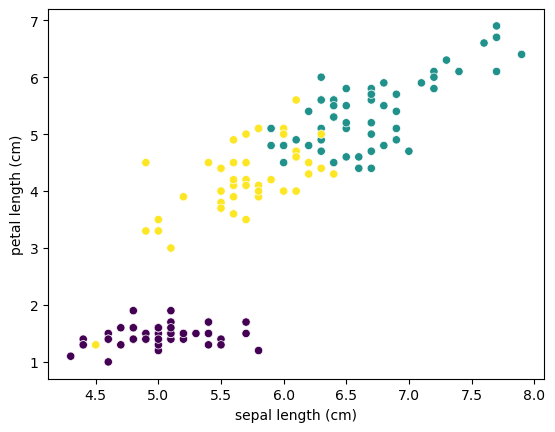

In [59]:
# applying the K-Means
km = KMeans(n_clusters=3)
labels = km.fit_predict(x_scaled)
sns.scatterplot(x=x.iloc[:,0], y=x.iloc[:,2], c = labels)

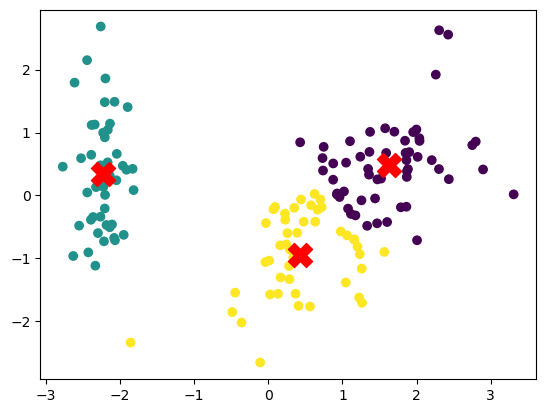

In [60]:
# optional- Dimmentional Reduction Using PCA
# PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(x_scaled)

# KMeans
km = KMeans(n_clusters=3, random_state=10)
labels = km.fit_predict(pca_data)

# Plot points
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=labels
)

# Plot centroids
plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    marker='X',
    s=300,
    c='red'
)